<a href="https://colab.research.google.com/github/vitoriaayres/YOLO_TESTES_MARI_INTERFOCUS/blob/main/TESTE1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt-get -qq update
!apt-get -qq install -y libzbar0
!pip -q install --upgrade opencv-contrib-python-headless pyzbar zxing-cpp

In [34]:
import math
import re
import shutil
from datetime import datetime
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import zxingcpp
from google.colab import files
from IPython.display import display
from pyzbar.pyzbar import decode as zbar_decode

plt.rcParams['figure.dpi']= 120
plt.rcParams['axes.titlesize']= 11

CONFIG= {
    'detection_max_side': 1800,
    'min_area_ratio': 0.00012,
    'max_area_ratio': 0.12,
    'min_aspect_ratio': 1.8,
    'max_aspect_ratio': 30.0,
    'min_rectangularity': 0.18,

    'min_edge_runs': 12,
    'min_dark_runs': 9,
    'min_row_transitions': 14,
    'min_valid_row_ratio': 0.58,
    'min_direction_ratio': 1.15,
    'min_signature_score': 0.60,

    'candidate_min_edge_runs': 8,
    'candidate_min_dark_runs': 6,
    'candidate_min_transitions': 10,
    'candidate_min_valid_row_ratio': 0.30,
    'candidate_min_direction_ratio': 1.00,
    'candidate_min_signature_score': 0.42,

    'nms_iou': 0.25,
    'confirmed_nms_iou': 0.20,
    'confirmed_containment': 0.70,
    'min_retail_symbol_width_ratio': 0.45,
    'validation_margin': 0.04,
    'decode_margin': 0.12,
}
print(f'OPENCV: {cv2.__version__}')
print(f'NUMPY: {np.__version__}')

OPENCV: 5.0.0
NUMPY: 2.0.2


In [35]:
def odd_size(value, minimum=3, maximum=61):
  value= int(np.clip(round(value), minimum, maximum))
  if value % 2 == 0:
    value += 1 if value < maximum else -1
  return value

def order_quad(points):
  points= np.asarray(points, dtype= np.float32)
  ordered= np.zeros((4,2), dtype=np.float32)
  sums= points.sum(axis=1)
  differences= np.diff(points, axis=1).ravel()
  ordered[0]= points[np.argmin(sums)]
  ordered[1]= points[np.argmin(differences)]
  ordered[2]= points[np.argmax(sums)]
  ordered[3]= points[np.argmax(differences)]
  return ordered

def extract_rotated_roi(image, rect, margin_ratio= 0.04):
  center, (rect_width, rect_height), angle= rect
  if rect_width <= 1 or rect_height <= 1:
    return None
  expanded= (
      center,
      (
          rect_width * (1.0 + 2.0 * margin_ratio),
          rect_height *(1.0 + 2.0 * margin_ratio),
      ),
      angle,
  )
  source= order_quad(cv2.boxPoints(expanded))
  top_left, top_right, bottom_right, bottom_left= source

  target_width= max(
      2,
      int(round(max(
          np.linalg.norm(top_right - top_left),
          np.linalg.norm(bottom_right - bottom_left),
      ))),
  )
  target_height= max(
      2,
      int(round(max(
          np.linalg.norm(bottom_left - top_left),
          np.linalg.norm(bottom_right - top_right),
      ))),
)
  destination= np.array(
      [
          [0,0],
          [target_width - 1, 0],
          [target_width -1, target_height -1],
          [0, target_height -1],
      ],
      dtype= np.float32,
  )
  matrix= cv2.getPerspectiveTransform(source, destination)
  aligned= cv2.warpPerspective(
      image,
      matrix,
      (target_width, target_height),
      flags= cv2.INTER_CUBIC,
      borderMode= cv2.BORDER_REPLICATE,
  )

  if aligned.shape[0] > aligned.shape[1]:
          aligned = cv2.rotate(aligned, cv2.ROTATE_90_CLOCKWISE)
  return aligned


def rect_to_bbox(rect, image_shape):
  box = cv2.boxPoints(rect).astype(np.float32)
  height, width = image_shape[:2]
  box[:, 0] = np.clip(box[:, 0], 0, width - 1)
  box[:, 1] = np.clip(box[:, 1], 0, height - 1)
  x, y, w, h = cv2.boundingRect(box.astype(np.int32))
  return box.astype(np.int32), (int(x), int(y), int(w), int(h))


def intersection_over_union(box_a, box_b):
  ax, ay, aw, ah = box_a
  bx, by, bw, bh = box_b
  left = max(ax, bx)
  top = max(ay, by)
  right = min(ax + aw, bx + bw)
  bottom = min(ay + ah, by + bh)
  intersection = max(0, right - left) * max(0, bottom - top)
  union = aw * ah + bw * bh - intersection
  return intersection / union if union > 0 else 0.0


def count_true_runs(values):
  values = np.asarray(values, dtype=np.uint8).ravel()
  if values.size == 0:
    return 0
  padded = np.pad(values, (1, 1), constant_values=0)
  changes = np.diff(padded.astype(np.int16))
  return int(np.count_nonzero(changes == 1))

In [36]:
def resize_for_detection(image, max_side):
      height, width = image.shape[:2]
      largest = max(height, width)
      if largest <= max_side:
          return image.copy(), 1.0
      scale = max_side / float(largest)
      resized = cv2.resize(
          image,
          (int(round(width * scale)), int(round(height * scale))),
          interpolation=cv2.INTER_AREA,
      )
      return resized, scale


def make_barcode_masks(image):
      gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
      normalized = cv2.createCLAHE(
          clipLimit=2.0, tileGridSize=(8, 8)
      ).apply(gray)
      blurred = cv2.GaussianBlur(normalized, (3, 3), 0)

      grad_x = np.abs(cv2.Sobel(blurred, cv2.CV_32F, 1, 0, ksize=3))
      grad_y = np.abs(cv2.Sobel(blurred, cv2.CV_32F, 0, 1, ksize=3))

      # Barras verticais produzem principalmente gradiente em X.
      response_horizontal = np.maximum(grad_x - 0.55 * grad_y, 0)
      # Barras horizontais, de um código girado, produzem gradiente em Y.
      response_vertical = np.maximum(grad_y - 0.55 * grad_x, 0)

      response_horizontal = cv2.normalize(
          response_horizontal, None, 0, 255, cv2.NORM_MINMAX
      ).astype(np.uint8)
      response_vertical = cv2.normalize(
          response_vertical, None, 0, 255, cv2.NORM_MINMAX
      ).astype(np.uint8)

      response_horizontal = cv2.GaussianBlur(response_horizontal, (3, 3), 0)
      response_vertical = cv2.GaussianBlur(response_vertical, (3, 3), 0)

      _, threshold_horizontal = cv2.threshold(
          response_horizontal, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
      )
      _, threshold_vertical = cv2.threshold(
          response_vertical, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
      )

      height, width = gray.shape
      reference = min(height, width)
      long_kernel = odd_size(reference * 0.026, 15, 55)
      short_kernel = odd_size(reference * 0.004, 3, 7)

      kernel_horizontal = cv2.getStructuringElement(
          cv2.MORPH_RECT, (long_kernel, short_kernel)
      )
      kernel_vertical = cv2.getStructuringElement(
          cv2.MORPH_RECT, (short_kernel, long_kernel)
      )
      cleanup = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

      mask_horizontal = cv2.morphologyEx(
          threshold_horizontal, cv2.MORPH_CLOSE, kernel_horizontal
      )
      mask_vertical = cv2.morphologyEx(
          threshold_vertical, cv2.MORPH_CLOSE, kernel_vertical
      )
      mask_horizontal = cv2.morphologyEx(
          mask_horizontal, cv2.MORPH_OPEN, cleanup
      )
      mask_vertical = cv2.morphologyEx(
          mask_vertical, cv2.MORPH_OPEN, cleanup
      )

      return {
          "gray": gray,
          "normalized": normalized,
          "response_horizontal": response_horizontal,
          "response_vertical": response_vertical,
          "threshold_horizontal": threshold_horizontal,
          "threshold_vertical": threshold_vertical,
          "mask_horizontal": mask_horizontal,
          "mask_vertical": mask_vertical,
      }

In [37]:
def barcode_signature(roi, config=CONFIG):
      rejected = {
          "accepted": False,
          "score": 0.0,
          "edge_runs": 0,
          "dark_runs": 0,
          "median_transitions": 0.0,
          "valid_row_ratio": 0.0,
          "direction_ratio": 0.0,
      }
      if roi is None or roi.size == 0:
          return rejected

      if roi.ndim == 3:
          gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
      else:
          gray = roi.copy()
      if gray.shape[0] > gray.shape[1]:
          gray = cv2.rotate(gray, cv2.ROTATE_90_CLOCKWISE)

      height, width = gray.shape
      if height < 10 or width < 45 or width / max(height, 1) < 1.5:
          return rejected

      normalized = cv2.createCLAHE(
          clipLimit=2.0, tileGridSize=(8, 8)
      ).apply(gray)
      normalized = cv2.GaussianBlur(normalized, (3, 3), 0)

      gx = np.abs(cv2.Sobel(normalized, cv2.CV_32F, 1, 0, ksize=3))
      gy = np.abs(cv2.Sobel(normalized, cv2.CV_32F, 0, 1, ksize=3))
      direction_ratio = float((gx.mean() + 1.0) / (gy.mean() + 1.0))

      nonzero_edges = gx[gx > 0]
      if nonzero_edges.size == 0:
          return rejected
      edge_threshold = max(18.0, float(np.percentile(nonzero_edges, 68)))
      edge_map = gx >= edge_threshold

      # Uma borda de barra deve existir em uma fração relevante da altura.
      column_coverage = edge_map.mean(axis=0)
      strong_edge_columns = column_coverage >= 0.28
      edge_runs = count_true_runs(strong_edge_columns)

      _, binary = cv2.threshold(
          normalized, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
      )
      dark = binary == 0

      # Barras escuras formam colunas contínuas; letras normalmente não.
      dark_column_coverage = dark.mean(axis=0)
      strong_dark_columns = dark_column_coverage >= 0.55
      dark_runs = count_true_runs(strong_dark_columns)

      # Um barcode mantém muitas transições ao longo de várias linhas.
      row_transitions = np.count_nonzero(
          dark[:, 1:] != dark[:, :-1], axis=1
      ).astype(np.float32)
      trim = max(1, int(round(height * 0.06)))
      central_rows = row_transitions[trim:height - trim]
      if central_rows.size == 0:
          central_rows = row_transitions
      median_transitions = float(np.median(central_rows))
      valid_row_ratio = float(np.mean(
          central_rows >= config["min_row_transitions"]
      ))

      edge_component = min(edge_runs / 24.0, 1.0)
      dark_component = min(dark_runs / 18.0, 1.0)
      transition_component = min(median_transitions / 32.0, 1.0)
      row_component = min(valid_row_ratio / 0.80, 1.0)
      direction_component = min(max(direction_ratio - 0.8, 0.0) / 1.2, 1.0)
      score = float(
          0.24 * edge_component
          + 0.22 * dark_component
          + 0.20 * transition_component
          + 0.22 * row_component
          + 0.12 * direction_component
      )

      accepted = bool(
          edge_runs >= config["min_edge_runs"]
          and dark_runs >= config["min_dark_runs"]
          and median_transitions >= config["min_row_transitions"]
          and valid_row_ratio >= config["min_valid_row_ratio"]
          and direction_ratio >= config["min_direction_ratio"]
          and score >= config["min_signature_score"]
      )

      return {
          "accepted": accepted,
          "score": score,
          "edge_runs": int(edge_runs),
          "dark_runs": int(dark_runs),
          "median_transitions": median_transitions,
          "valid_row_ratio": valid_row_ratio,
          "direction_ratio": direction_ratio,
      }


def has_barcode_potential(signature, config=CONFIG):
      # O decoder decide o resultado final. Esta etapa só evita perder barras reais
      # pouco contrastadas, pequenas ou próximas de outros códigos.
      return bool(
          signature["accepted"]
          or (
              signature["edge_runs"] >= config["candidate_min_edge_runs"]
              and signature["dark_runs"] >= config["candidate_min_dark_runs"]
              and signature["median_transitions"]
              >= config["candidate_min_transitions"]
              and signature["valid_row_ratio"]
              >= config["candidate_min_valid_row_ratio"]
              and signature["direction_ratio"]
              >= config["candidate_min_direction_ratio"]
              and signature["score"]
              >= config["candidate_min_signature_score"]
          )
      )

In [38]:
def geometric_candidates(mask, image_shape, orientation, config=CONFIG):
      contours, _ = cv2.findContours(
          mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
      )
      image_height, image_width = image_shape[:2]
      image_area = image_height * image_width
      reference = min(image_height, image_width)
      minimum_long_side = max(35.0, reference * 0.025)
      minimum_short_side = max(7.0, reference * 0.006)

      proposals = []
      for contour in contours:
          contour_area = float(cv2.contourArea(contour))
          if contour_area <= 0:
              continue
          rect = cv2.minAreaRect(contour)
          rect_width, rect_height = rect[1]
          if rect_width <= 1 or rect_height <= 1:
              continue

          long_side = max(rect_width, rect_height)
          short_side = min(rect_width, rect_height)
          aspect_ratio = long_side / max(short_side, 1.0)
          rect_area = rect_width * rect_height
          area_ratio = rect_area / image_area
          rectangularity = contour_area / max(rect_area, 1.0)

          if not (
              config["min_area_ratio"] <= area_ratio <= config["max_area_ratio"]
              and config["min_aspect_ratio"] <= aspect_ratio <= config["max_aspect_ratio"]
              and rectangularity >= config["min_rectangularity"]
              and long_side >= minimum_long_side
              and short_side >= minimum_short_side
          ):
              continue

          box, bbox = rect_to_bbox(rect, image_shape)
          proposals.append({
              "rect": rect,
              "box": box,
              "bbox": bbox,
              "orientation": orientation,
              "area_ratio": float(area_ratio),
              "aspect_ratio": float(aspect_ratio),
              "rectangularity": float(rectangularity),
          })
      return proposals


def scale_rect(rect, factor):
      center, size, angle = rect
      return (
          (center[0] * factor, center[1] * factor),
          (size[0] * factor, size[1] * factor),
          angle,
      )


def locate_bar_regions(image, config=CONFIG, return_steps=False):
      if image is None or not isinstance(image, np.ndarray) or image.size == 0:
          raise ValueError("A imagem fornecida é inválida.")
      if image.ndim != 3 or image.shape[2] != 3:
          raise ValueError("Use uma imagem BGR com três canais.")

      working, scale = resize_for_detection(
          image, config["detection_max_side"]
      )
      steps = make_barcode_masks(working)

      proposals = []
      proposals.extend(geometric_candidates(
          steps["mask_horizontal"], working.shape, "horizontal", config
      ))
      proposals.extend(geometric_candidates(
          steps["mask_vertical"], working.shape, "vertical", config
      ))

      validated = []
      for proposal in proposals:
          validation_roi = extract_rotated_roi(
              working,
              proposal["rect"],
              config["validation_margin"],
          )
          signature = barcode_signature(validation_roi, config)
          if not has_barcode_potential(signature, config):
              continue
          proposal = dict(proposal)
          proposal["signature"] = signature
          proposal["ranking_score"] = float(
              signature["score"]
              + 0.08 * min(proposal["aspect_ratio"] / 8.0, 1.0)
              + 0.04 * proposal["rectangularity"]
          )
          validated.append(proposal)

      validated.sort(key=lambda item: item["ranking_score"], reverse=True)
      selected = []
      for proposal in validated:
          if all(
              intersection_over_union(proposal["bbox"], kept["bbox"])
              < config["nms_iou"]
              for kept in selected
          ):
              selected.append(proposal)

      # Volta às coordenadas da imagem original e revalida em resolução cheia.
      factor = 1.0 / scale
      results = []
      for proposal in selected:
          original_rect = scale_rect(proposal["rect"], factor)
          tight_roi = extract_rotated_roi(
              image, original_rect, config["validation_margin"]
          )
          full_signature = barcode_signature(tight_roi, config)
          if not has_barcode_potential(full_signature, config):
              continue

          decode_roi = extract_rotated_roi(
              image, original_rect, config["decode_margin"]
          )
          box, bbox = rect_to_bbox(original_rect, image.shape)
          results.append({
              "rect": original_rect,
              "box": box,
              "bbox": bbox,
              "orientation": proposal["orientation"],
              "signature": full_signature,
              "tight_roi": tight_roi,
              "decode_roi": decode_roi,
          })

      results.sort(key=lambda item: (item["bbox"][1], item["bbox"][0]))
      for index, result in enumerate(results, start=1):
          result["barcode_id"] = index

      if return_steps:
          return results, steps, scale, len(proposals)
      return results

In [39]:
def text_value(value):
      if isinstance(value, bytes):
          return value.decode("utf-8", errors="replace").strip()
      if isinstance(value, str):
          return value.strip()
      if isinstance(value, (list, tuple)):
          for item in value:
              result = text_value(item)
              if result:
                  return result
      if isinstance(value, np.ndarray) and value.dtype.kind in {"U", "S", "O"}:
          for item in value.ravel().tolist():
              result = text_value(item)
              if result:
                  return result
      return ""


def decode_opencv(image):
      detector_class = getattr(cv2, "barcode_BarcodeDetector", None)
      if detector_class is None and hasattr(cv2, "barcode"):
          detector_class = getattr(cv2.barcode, "BarcodeDetector", None)
      if detector_class is None:
          return None

      detector = detector_class()
      for method_name in ("detectAndDecodeWithType", "detectAndDecode"):
          method = getattr(detector, method_name, None)
          if method is None:
              continue
          try:
              output = method(image)
          except (cv2.error, TypeError):
              continue
          if not isinstance(output, tuple):
              continue

          if len(output) == 4:
              value = text_value(output[1])
              barcode_type = text_value(output[2])
              points = output[3]
          elif len(output) == 3:
              value = text_value(output[0])
              barcode_type = ""
              points = output[2]
          else:
              continue

          symbol_width_ratio = 1.0
          try:
              point_array = np.asarray(points, dtype=np.float32).reshape(-1, 2)
              if point_array.size:
                  symbol_width_ratio = float(
                      (point_array[:, 0].max() - point_array[:, 0].min())
                      / max(image.shape[1], 1)
                  )
          except (TypeError, ValueError):
              pass

          if value:
              return {
                  "decoded": True,
                  "value": value,
                  "type": barcode_type or "OpenCV",
                  "decoder": "OpenCV",
                  "symbol_width_ratio": symbol_width_ratio,
              }
      return None


def decode_pyzbar(image):
      try:
          items = zbar_decode(image)
      except Exception:
          return None
      if not items:
          return None
      item = items[0]
      symbol_width_ratio = float(item.rect.width / max(image.shape[1], 1))
      return {
          "decoded": True,
          "value": item.data.decode("utf-8", errors="replace"),
          "type": item.type or "ZBar",
          "decoder": "pyzbar",
          "symbol_width_ratio": symbol_width_ratio,
      }


def decode_zxing(image):
      try:
          items = zxingcpp.read_barcodes(
              image, try_rotate=True, try_downscale=True, try_invert=True
          )
      except Exception:
          return None
      if not items:
          return None
      item = items[0]
      value = str(item.text).strip()
      if not item.valid or not value:
          return None
      position = item.position
      xs = [
          position.top_left.x, position.top_right.x,
          position.bottom_right.x, position.bottom_left.x,
      ]
      symbol_width_ratio = float((max(xs) - min(xs)) / max(image.shape[1], 1))
      return {
          "decoded": True,
          "value": value,
          "type": str(item.format),
          "decoder": "ZXing-C++",
          "symbol_width_ratio": symbol_width_ratio,
      }


def decode_validated_roi(roi):
      if roi is None or roi.size == 0:
          return {
              "decoded": False,
              "value": "",
              "type": "Não identificado",
              "decoder": "Nenhum",
              "variant": "Nenhuma",
          }

      height, width = roi.shape[:2]
      pad_y = max(12, int(round(height * 0.22)))
      pad_x = max(24, int(round(width * 0.08)))
      padded = cv2.copyMakeBorder(
          roi,
          pad_y,
          pad_y,
          pad_x,
          pad_x,
          cv2.BORDER_CONSTANT,
          value=(255, 255, 255),
      )

      gray = cv2.cvtColor(padded, cv2.COLOR_BGR2GRAY)
      clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)
      _, otsu = cv2.threshold(
          clahe, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
      )
      scale = float(np.clip(180.0 / max(height, 1), 2.0, 5.0))
      enlarged_gray = cv2.resize(
          clahe, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC
      )
      enlarged_binary = cv2.resize(
          otsu, None, fx=scale, fy=scale, interpolation=cv2.INTER_NEAREST
      )
      sharpened = cv2.filter2D(
          enlarged_gray,
          -1,
          np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32),
      )

      variants = [
          ("ROI com zona branca", padded),
          ("Escala de cinza", gray),
          ("Contraste local", clahe),
          ("Otsu", otsu),
          ("Ampliada", enlarged_gray),
          ("Ampliada binária", enlarged_binary),
          ("Nitidez", sharpened),
      ]

      # ZXing-C++ é tentado primeiro por ser mais robusto em recortes pequenos.
      for name, variant in variants:
          result = decode_zxing(variant)
          if result:
              result["variant"] = name
              return result

      # ZBar fornece uma segunda implementação para Code 128 e outros formatos 1D.
      for name, variant in variants:
          result = decode_pyzbar(variant)
          if result:
              result["variant"] = name
              return result

      for name, variant in variants:
          result = decode_opencv(variant)
          if result:
              result["variant"] = name
              return result

      return {
          "decoded": False,
          "value": "",
          "type": "Não identificado",
          "decoder": "Nenhum",
          "variant": "Nenhuma",
      }


def decode_regions(regions):
      for region in regions:
          # Primeiro corta somente as barras. A margem maior é apenas fallback.
          attempts = [
              ("Recorte isolado", region["tight_roi"]),
              ("Recorte com margem", region["decode_roi"]),
          ]
          final_result = None

          for crop_name, crop in attempts:
              result = decode_validated_roi(crop)
              if result["decoded"]:
                  result["crop"] = crop_name
                  final_result = result
                  break

          if final_result is None:
              final_result = decode_validated_roi(region["decode_roi"])
              final_result["crop"] = "Nenhum"

          region.update(final_result)

      return regions


def decode_zxing_full_image_regions(image, config=CONFIG):
      # Uma leitura global preserva códigos próximos como símbolos independentes.
      try:
          items = zxingcpp.read_barcodes(
              image, try_rotate=True, try_downscale=True, try_invert=True
          )
      except Exception:
          return []

      regions = []
      for item in items:
          value = str(item.text).strip()
          if not item.valid or not value:
              continue

          position = item.position
          points = np.array([
              [position.top_left.x, position.top_left.y],
              [position.top_right.x, position.top_right.y],
              [position.bottom_right.x, position.bottom_right.y],
              [position.bottom_left.x, position.bottom_left.y],
          ], dtype=np.float32)

          rect = cv2.minAreaRect(points)
          rect_width, rect_height = rect[1]

          if max(rect_width, rect_height) < 12:
              continue

          if min(rect_width, rect_height) < 6:
              # Alguns leitores retornam uma linha central para símbolos 1D.
              long_side = max(rect_width, rect_height)
              short_side = max(12.0, long_side * 0.12)

              if rect_width >= rect_height:
                  rect = (rect[0], (long_side, short_side), rect[2])
              else:
                  rect = (rect[0], (short_side, long_side), rect[2])

          tight_roi = extract_rotated_roi(
              image, rect, config["validation_margin"]
          )
          decode_roi = extract_rotated_roi(
              image, rect, config["decode_margin"]
          )

          signature = barcode_signature(tight_roi, config)
          signature = dict(signature)
          signature["accepted"] = True
          signature["score"] = max(signature["score"], 0.95)

          box, bbox = rect_to_bbox(rect, image.shape)
          regions.append({
              "rect": rect,
              "box": box,
              "bbox": bbox,
              "orientation": "ZXing imagem completa",
              "signature": signature,
              "tight_roi": tight_roi,
              "decode_roi": decode_roi,
              "decoded": True,
              "value": value,
              "type": str(item.format),
              "decoder": "ZXing-C++",
              "variant": "Imagem completa",
              "crop": "Polígono do decoder",
              "symbol_width_ratio": 1.0,
          })

      return regions


ONE_DIMENSIONAL_BARCODE_TYPES = {
      "CODABAR", "CODE39", "CODE93", "CODE128",
      "DATABAR", "DATABAREXP", "DATABAREXPANDED",
      "DATABARLIMITED", "EAN2", "EAN5", "EAN8", "EAN13",
      "I25", "ITF", "ISBN10", "ISBN13",
      "UPCA", "UPCE",
  }


def normalized_barcode_type(value):
    return re.sub(r"[^A-Z0-9]+", "", str(value).upper())
def is_confirmed_1d_barcode(region):
    barcode_type = normalized_barcode_type(region.get("type", ""))
    retail_types = {"EAN8", "EAN13", "UPCA", "UPCE"}
    width_ratio = float(region.get("symbol_width_ratio", 1.0))
    return bool(
        region.get("decoded")
        and str(region.get("value", "")).strip()
        and barcode_type in ONE_DIMENSIONAL_BARCODE_TYPES
        and (
            barcode_type not in retail_types
            or width_ratio >= CONFIG["min_retail_symbol_width_ratio"]
        )
    )
def intersection_over_smaller(box_a, box_b):
      ax, ay, aw, ah = box_a
      bx, by, bw, bh = box_b
      left = max(ax, bx)
      top = max(ay, by)
      right = min(ax + aw, bx + bw)
      bottom = min(ay + ah, by + bh)
      intersection = max(0, right - left) * max(0, bottom - top)
      smaller_area = min(aw * ah, bw * bh)
      return intersection / smaller_area if smaller_area > 0 else 0.0


def keep_confirmed_barcodes(regions, config=CONFIG):
      # Regra central do modo estrito: sem valor decodificado, não há detecção final.
      confirmed = [
          region
          for region in regions
          if is_confirmed_1d_barcode(region)
      ]
      confirmed.sort(
          key=lambda item: item["signature"]["score"],
          reverse=True,
      )

      selected = []
      for region in confirmed:
          is_duplicate = any(
              intersection_over_union(
                  region["bbox"], kept["bbox"]
              ) >= config["confirmed_nms_iou"]
              or intersection_over_smaller(
                  region["bbox"], kept["bbox"]
              ) >= config["confirmed_containment"]
              for kept in selected
          )

          if not is_duplicate:
              selected.append(region)

      selected.sort(
          key=lambda item: (
              item["bbox"][1],
              item["bbox"][0],
          )
      )

      for index, region in enumerate(selected, start=1):
          region["barcode_id"] = index

      return selected

In [40]:
def show_bgr(image, title, figsize=(13, 8)):
      plt.figure(figsize=figsize)
      plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
      plt.title(title)
      plt.axis("off")
      plt.tight_layout()
      plt.show()


def annotate_confirmed_barcodes(image, regions):
      annotated = image.copy()
      image_height, image_width = image.shape[:2]
      line_width = max(2, int(round(max(image_height, image_width) / 700)))

      for region in regions:
          # Defesa adicional: candidatos não decodificados nunca são desenhados.
          if not is_confirmed_1d_barcode(region):
              continue

          box = region["box"].astype(np.int32)
          cv2.polylines(
              annotated,
              [box],
              True,
              (0, 220, 0),
              line_width,
              cv2.LINE_AA,
          )

          x, y, _, h = region["bbox"]
          label = (
              f"Barcode {region['barcode_id']} | "
              f"{region['type']}: {region['value']}"
          )

          font_scale = max(0.45, min(0.75, image_width / 1500.0))
          thickness = max(1, line_width - 1)
          (text_width, text_height), baseline = cv2.getTextSize(
              label,
              cv2.FONT_HERSHEY_SIMPLEX,
              font_scale,
              thickness,
          )

          text_x = int(
              np.clip(
                  x,
                  0,
                  max(0, image_width - text_width - 10),
              )
          )
          text_y = (
              y - 10
              if y > text_height + 16
              else min(
                  image_height - 8,
                  y + h + text_height + 12,
              )
          )

          cv2.rectangle(
              annotated,
              (text_x, max(0, text_y - text_height - 6)),
              (
                  min(image_width - 1, text_x + text_width + 8),
                  min(image_height - 1, text_y + baseline + 4),
              ),
              (20, 20, 20),
              -1,
          )

          cv2.putText(
              annotated,
              label,
              (text_x + 4, text_y),
              cv2.FONT_HERSHEY_SIMPLEX,
              font_scale,
              (255, 255, 255),
              thickness,
              cv2.LINE_AA,
          )

      return annotated


def regions_dataframe(regions, image_name=""):
      rows = []

      for region in regions:
          x, y, w, h = region["bbox"]
          signature = region["signature"]

          rows.append({
              "arquivo": image_name,
              "barcode_id": region["barcode_id"],
              "valor": region["value"],
              "tipo": region["type"],
              "decodificado": region["decoded"],
              "x": x,
              "y": y,
              "largura": w,
              "altura": h,
              "signature_score": round(signature["score"], 4),
              "edge_runs": signature["edge_runs"],
              "dark_runs": signature["dark_runs"],
              "valid_row_ratio": round(
                  signature["valid_row_ratio"],
                  4,
              ),
              "direction_ratio": round(
                  signature["direction_ratio"],
                  4,
              ),
              "decoder": region["decoder"],
              "variante": region["variant"],
          })

      return pd.DataFrame(rows)


def show_debug_steps(
      image,
      steps,
      scale,
      regions,
      proposal_count,
  ):
      working, _ = resize_for_detection(
          image,
          CONFIG["detection_max_side"],
      )
      accepted_preview = working.copy()

      for region in regions:
          scaled_box = np.round(
              region["box"] * scale
          ).astype(np.int32)

          cv2.polylines(
              accepted_preview,
              [scaled_box],
              True,
              (0, 220, 0),
              3,
              cv2.LINE_AA,
          )

      panels = [
          (
              cv2.cvtColor(working, cv2.COLOR_BGR2RGB),
              "Imagem",
              None,
          ),
          (
              steps["response_horizontal"],
              "Gradiente: barras verticais",
              "gray",
          ),
          (
              steps["mask_horizontal"],
              "Propostas horizontais",
              "gray",
          ),
          (
              steps["response_vertical"],
              "Gradiente: barras horizontais",
              "gray",
          ),
          (
              steps["mask_vertical"],
              "Propostas verticais",
              "gray",
          ),
          (
              cv2.cvtColor(
                  accepted_preview,
                  cv2.COLOR_BGR2RGB,
              ),
              (
                  f"Confirmados pelo decoder: "
                  f"{len(regions)} de {proposal_count} propostas"
              ),
              None,
          ),
      ]

      fig, axes = plt.subplots(2, 3, figsize=(18, 10))

      for axis, (panel, title, cmap) in zip(
          axes.ravel(),
          panels,
      ):
          axis.imshow(panel, cmap=cmap)
          axis.set_title(title)
          axis.axis("off")

      plt.tight_layout()
      plt.show()


def show_confirmed_rois(regions):
      if not regions:
          print(
              "Nenhum código de barras foi confirmado pelo decoder."
          )
          return

      fig, axes = plt.subplots(
          len(regions),
          1,
          figsize=(14, 3.2 * len(regions)),
      )
      axes = np.atleast_1d(axes)

      for axis, region in zip(axes, regions):
          axis.imshow(
              cv2.cvtColor(
                  region["decode_roi"],
                  cv2.COLOR_BGR2RGB,
              )
          )
          value = region["value"]
          axis.set_title(
              f"Barcode {region['barcode_id']} | {value} | "
              f"assinatura {region['signature']['score']:.3f}"
          )
          axis.axis("off")

      plt.tight_layout()
      plt.show()


def analyze_barcode_image(
      image,
      image_name="imagem",
      show_debug=True,
  ):
      candidates, steps, scale, proposal_count = locate_bar_regions(
          image,
          CONFIG,
          return_steps=True,
      )

      decode_regions(candidates)

      direct_regions = decode_zxing_full_image_regions(
          image,
          CONFIG,
      )

      regions = keep_confirmed_barcodes(
          candidates + direct_regions,
          CONFIG,
      )

      annotated = annotate_confirmed_barcodes(
          image,
          regions,
      )

      if show_debug:
          show_debug_steps(
              image,
              steps,
              scale,
              regions,
              proposal_count,
          )

      show_bgr(
          annotated,
          f"{image_name}: somente códigos de barras confirmados",
      )

      show_confirmed_rois(regions)

      table = regions_dataframe(
          regions,
          image_name,
      )
      display(table)

      return regions, annotated, table

Saving imagem_oito.jpg to imagem_oito (3).jpg

Analisando: imagem_oito (3).jpg


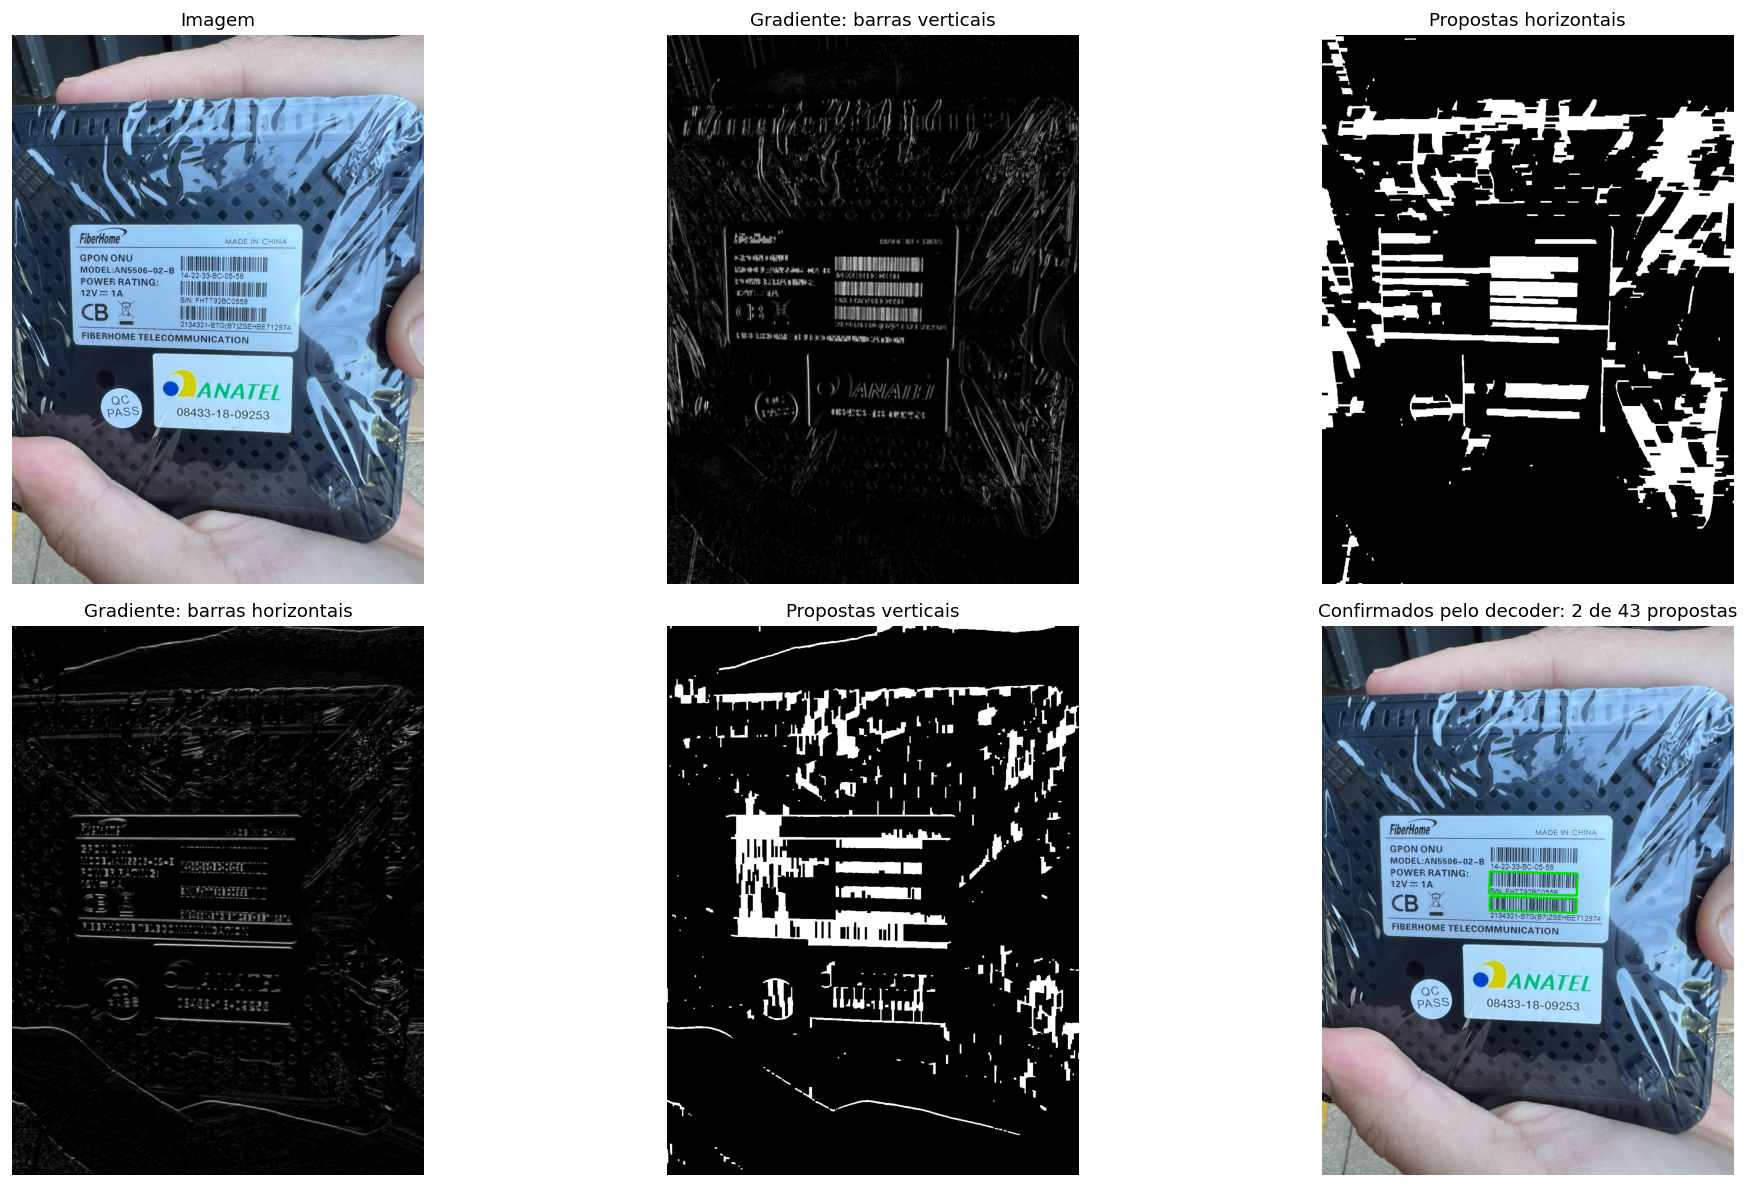

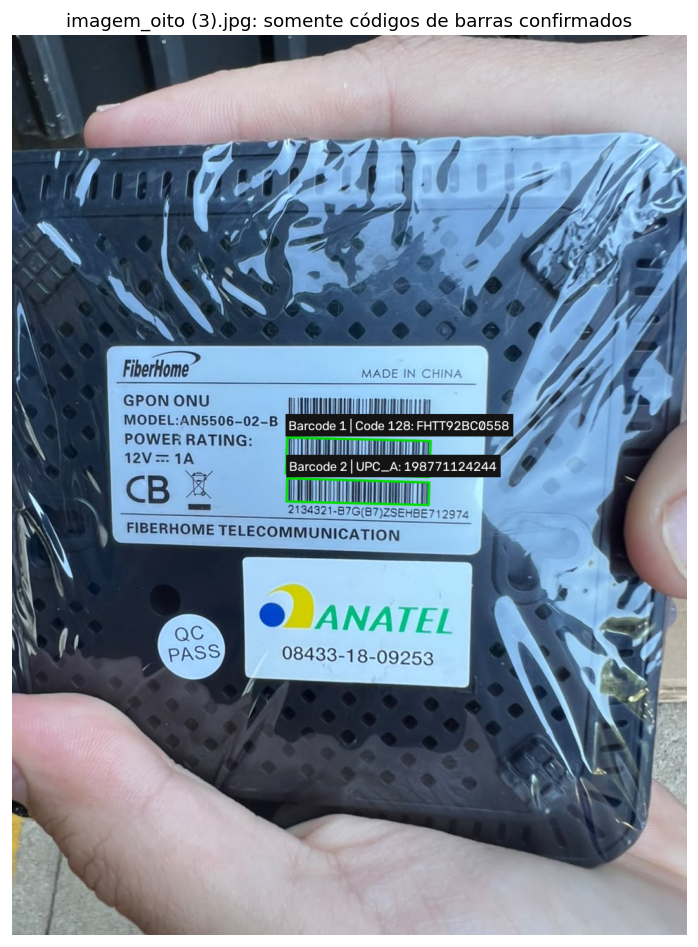

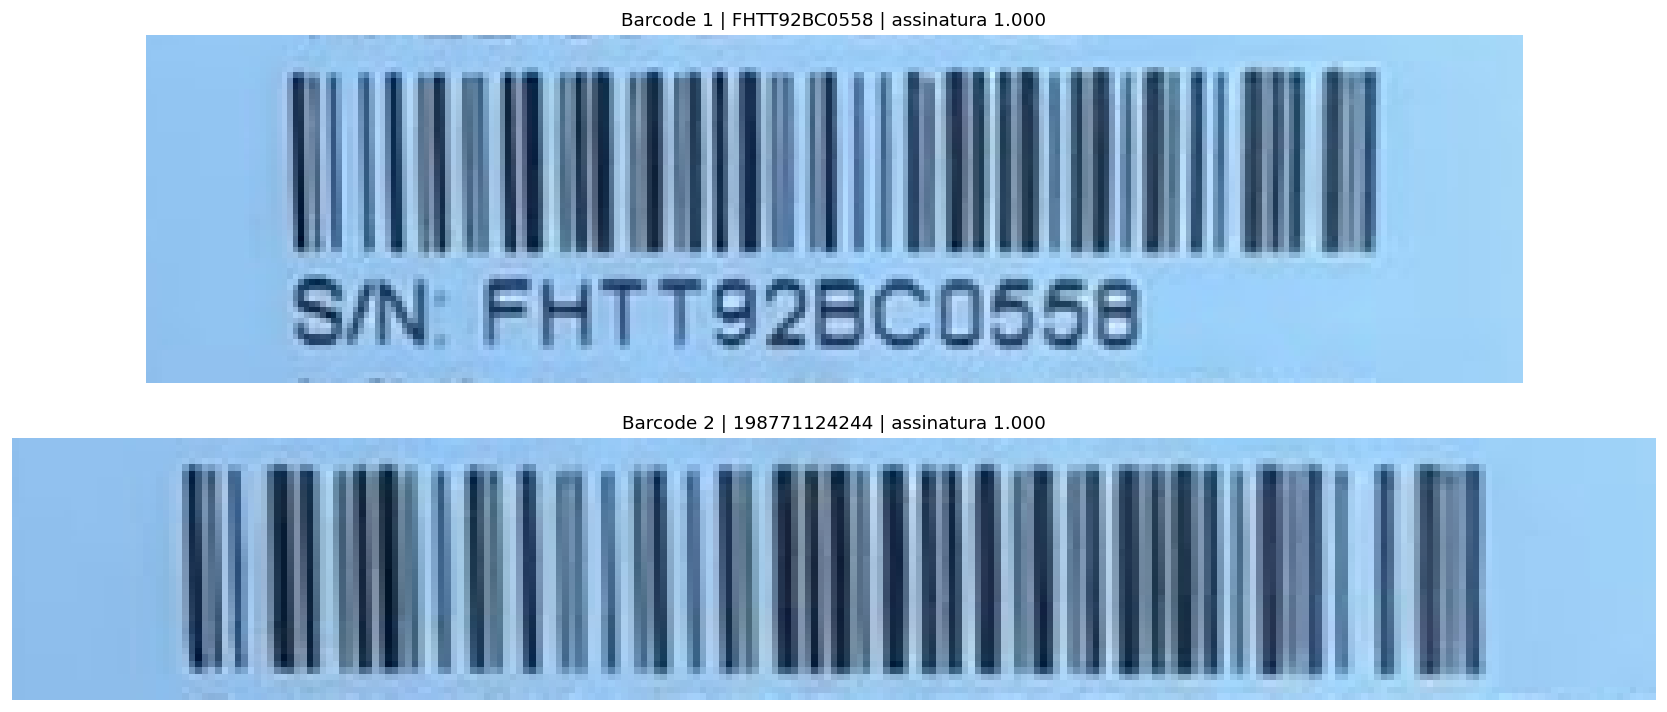

,arquivo,barcode_id,valor,tipo,decodificado,x,y,largura,altura,signature_score,edge_runs,dark_runs,valid_row_ratio,direction_ratio,decoder,variante
0,imagem_oito (3).jpg,1,FHTT92BC0558,Code 128,True,389,572,207,57,1.0,63,29,0.92,2.7603,ZXing-C++,Ampliada
1,imagem_oito (3).jpg,2,198771124244,UPC_A,True,390,630,204,39,1.0,50,25,1.00,5.6555,OpenCV,Nitidez


,arquivo,barcode_id,valor,tipo,decodificado,x,y,largura,altura,signature_score,edge_runs,dark_runs,valid_row_ratio,direction_ratio,decoder,variante
0,imagem_oito (3).jpg,1,FHTT92BC0558,Code 128,True,389,572,207,57,1.0,63,29,0.92,2.7603,ZXing-C++,Ampliada
1,imagem_oito (3).jpg,2,198771124244,UPC_A,True,390,630,204,39,1.0,50,25,1.00,5.6555,OpenCV,Nitidez


Resultados salvos em: barcode_results_20260812_155003
Arquivo ZIP criado: /content/barcode_results_20260812_155003.zip


In [50]:
def decode_uploaded_image(content):
      data = np.frombuffer(content, dtype=np.uint8)
      image = cv2.imdecode(data, cv2.IMREAD_COLOR)

      if image is None or image.size == 0:
          raise ValueError(
              "O arquivo não pôde ser lido como imagem."
          )

      return image


def safe_name(filename):
      stem = Path(filename).stem
      stem = re.sub(
          r"[^A-Za-z0-9._-]+",
          "_",
          stem,
      ).strip("._")
      return stem or "imagem"


uploaded = files.upload()

if not uploaded:
      raise ValueError("Nenhuma imagem foi enviada.")


run_directory = Path(
    f"barcode_results_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
)
run_directory.mkdir(
    parents=True,
    exist_ok=False,
)

all_tables = []
run_results = {}

for filename, content in uploaded.items():
    print(f"\nAnalisando: {filename}")

    try:
        image = decode_uploaded_image(content)
    except ValueError as error:
        print(f"Ignorado: {error}")
        continue

    regions, annotated, table = analyze_barcode_image(
        image,
        filename,
        show_debug=True,
    )

    all_tables.append(table)
    run_results[filename] = regions

    image_directory = (
        run_directory / safe_name(filename)
    )
    roi_directory = (
        image_directory / "validated_barcode_rois"
    )
    roi_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    cv2.imwrite(
        str(
            image_directory
            / "final_result_annotated.png"
        ),
        annotated,
    )

    for region in regions:
        value = safe_name(
            region["value"] or "not_decoded"
        )
        roi_name = (
            f"barcode_{region['barcode_id']}_{value}.png"
        )
        cv2.imwrite(
            str(roi_directory / roi_name),
            region["decode_roi"],
        )

    table.to_csv(
        image_directory / "detections.csv",
        index=False,
    )


if all_tables:
    summary = pd.concat(
        all_tables,
        ignore_index=True,
    )
else:
    summary = pd.DataFrame()


summary.to_csv(
    run_directory / "all_detections.csv",
    index=False,
)
display(summary)


archive_path = shutil.make_archive(
    str(run_directory),
    "zip",
    root_dir=run_directory,
)

print(f"Resultados salvos em: {run_directory}")
print(f"Arquivo ZIP criado: {archive_path}")

In [47]:
files.download(archive_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

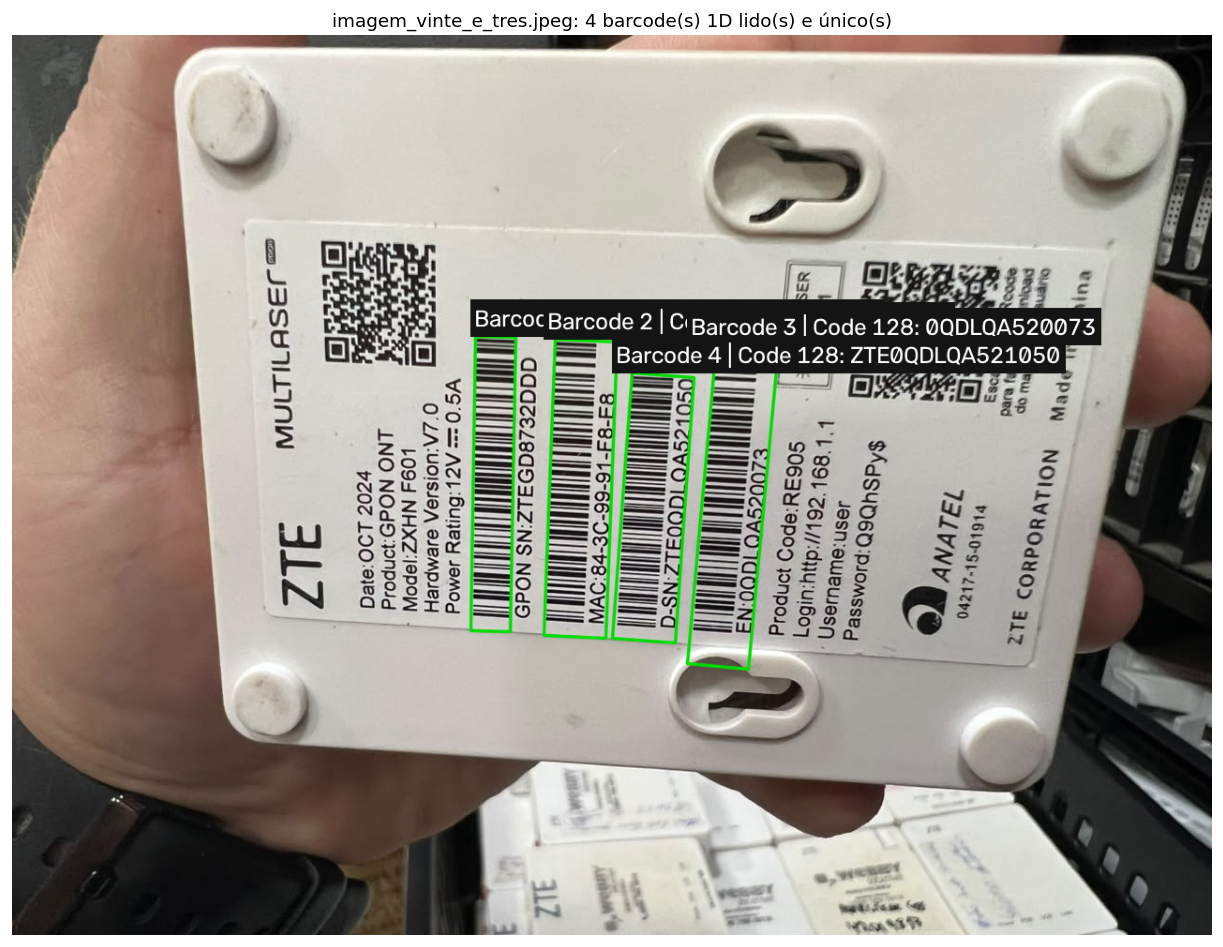

,arquivo,barcode_id,tipo,valor,x,y,largura,altura,decoder
0,imagem_vinte_e_tres.jpeg,1,Code 128,ZTEGD8732DDD,489,321,49,316,ZXing-C++
1,imagem_vinte_e_tres.jpeg,2,Code 128,843C9991F8E8,567,324,79,320,ZXing-C++
2,imagem_vinte_e_tres.jpeg,3,Code 128,0QDLQA520073,720,330,98,347,ZXing-C++
3,imagem_vinte_e_tres.jpeg,4,Code 128,ZTE0QDLQA521050,640,360,88,289,ZXing-C++


Saída final salva em: only_decoded_barcodes_20260812_154941
ZIP final criado: /content/only_decoded_barcodes_20260812_154941.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
if "uploaded" not in globals() or "run_results" not in globals():
    raise RuntimeError(
        "Execute primeiro a célula de upload e análise."
    )


FINAL_1D_TYPES = {
    "CODABAR",
    "CODE39",
    "CODE93",
    "CODE128",
    "DATABAR",
    "DATABAREXP",
    "DATABAREXPANDED",
    "DATABARLIMITED",
    "EAN2",
    "EAN5",
    "EAN8",
    "EAN13",
    "I25",
    "ITF",
    "ISBN10",
    "ISBN13",
    "UPCA",
    "UPCE",
}


def final_type_name(value):
    return re.sub(
        r"[^A-Z0-9]+",
        "",
        str(value).upper(),
    )


def final_unique_barcodes(regions):
    # A melhor região de cada par tipo+valor é mantida;
    # todo o resto é descartado.
    ordered = sorted(
        regions,
        key=lambda item: (
            item
            .get("signature", {})
            .get("score", 0.0)
        ),
        reverse=True,
    )

    unique = []
    seen = set()

    for region in ordered:
        barcode_type = final_type_name(
            region.get("type", "")
        )
        value = str(
            region.get("value", "")
        ).strip()

        if not region.get("decoded") or not value:
            continue

        if barcode_type not in FINAL_1D_TYPES:
            continue

        key = (barcode_type, value)

        if key in seen:
            continue

        seen.add(key)
        unique.append(region)

    unique.sort(
        key=lambda item: (
            item["bbox"][1],
            item["bbox"][0],
        )
    )

    for barcode_id, region in enumerate(
        unique,
        start=1,
    ):
        region["final_barcode_id"] = barcode_id

    return unique


def draw_only_final_barcodes(image, regions):
    output = image.copy()
    image_height, image_width = image.shape[:2]

    line_width = max(
        2,
        int(
            round(
                max(image_height, image_width) / 600
            )
        ),
    )

    font_scale = max(
        0.5,
        min(
            0.85,
            image_width / 1400.0,
        ),
    )

    thickness = max(1, line_width - 1)

    for region in regions:
        box = np.asarray(
            region["box"],
            dtype=np.int32,
        )

        cv2.polylines(
            output,
            [box],
            True,
            (0, 220, 0),
            line_width,
            cv2.LINE_AA,
        )

        x, y, _, h = region["bbox"]

        label = (
            f"Barcode {region['final_barcode_id']} | "
            f"{region['type']}: {region['value']}"
        )

        (
            text_width,
            text_height,
        ), baseline = cv2.getTextSize(
            label,
            cv2.FONT_HERSHEY_SIMPLEX,
            font_scale,
            thickness,
        )

        text_x = int(
            np.clip(
                x,
                0,
                max(
                    0,
                    image_width - text_width - 10,
                ),
            )
        )

        text_y = (
            y - 10
            if y > text_height + 16
            else min(
                image_height - 8,
                y + h + text_height + 12,
            )
        )

        cv2.rectangle(
            output,
            (
                text_x,
                max(
                    0,
                    text_y - text_height - 6,
                ),
            ),
            (
                min(
                    image_width - 1,
                    text_x + text_width + 8,
                ),
                min(
                    image_height - 1,
                    text_y + baseline + 4,
                ),
            ),
            (20, 20, 20),
            -1,
        )

        cv2.putText(
            output,
            label,
            (text_x + 4, text_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            font_scale,
            (255, 255, 255),
            thickness,
            cv2.LINE_AA,
        )

    return output


final_directory = Path(
    f"only_decoded_barcodes_"
    f"{datetime.now().strftime('%Y%m%d_%H%M%S')}"
)
final_directory.mkdir(
    parents=True,
    exist_ok=False,
)

final_rows = []
final_images = {}

for filename, content in uploaded.items():
    original = decode_uploaded_image(content)

    unique_regions = final_unique_barcodes(
        run_results.get(filename, [])
    )

    final_image = draw_only_final_barcodes(
        original,
        unique_regions,
    )

    final_images[filename] = final_image

    output_name = (
        f"{safe_name(filename)}"
        f"_only_decoded_barcodes.png"
    )

    cv2.imwrite(
        str(final_directory / output_name),
        final_image,
    )

    show_bgr(
        final_image,
        (
            f"{filename}: "
            f"{len(unique_regions)} "
            f"barcode(s) 1D lido(s) e único(s)"
        ),
    )

    for region in unique_regions:
        x, y, w, h = region["bbox"]

        final_rows.append({
            "arquivo": filename,
            "barcode_id": region["final_barcode_id"],
            "tipo": region["type"],
            "valor": region["value"],
            "x": x,
            "y": y,
            "largura": w,
            "altura": h,
            "decoder": region["decoder"],
        })


final_summary = pd.DataFrame(final_rows)

final_summary.to_csv(
    final_directory / "only_decoded_barcodes.csv",
    index=False,
)

display(final_summary)


final_archive = shutil.make_archive(
    str(final_directory),
    "zip",
    root_dir=final_directory,
)

print(
    f"Saída final salva em: {final_directory}"
)
print(
    f"ZIP final criado: {final_archive}"
)

files.download(final_archive)